<a href="https://colab.research.google.com/github/rc2308/churn-ensemble-engine/blob/main/notebooks/churn_ensemble_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Behavioral Segmentation & Churn Prediction Engine
Clustering → XGBoost + LightGBM Ensemble → SHAP → Dual-Mode Dashboard
Dataset: Churn_Modelling.csv (10,000 labeled rows, target = Exited)


In [4]:
!pip install -q xgboost lightgbm shap gradio


In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported.")


Libraries imported.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os
# Folder in your Drive to store dataset + artifacts
PROJECT_DIR = '/content/drive/MyDrive/churn-ensemble-engine'
ARTIFACTS_DIR = os.path.join(PROJECT_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print("Project dir:", PROJECT_DIR)
print("Artifacts dir:", ARTIFACTS_DIR)


Mounted at /content/drive
Project dir: /content/drive/MyDrive/churn-ensemble-engine
Artifacts dir: /content/drive/MyDrive/churn-ensemble-engine/artifacts


In [7]:
from google.colab import files
uploaded = files.upload()

Saving Churn_Modelling.csv to Churn_Modelling.csv


In [8]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
df.head()


Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df = df.drop(["RowNumber", "CustomerId", "Surname"], axis=1)
print("Shape after dropping IDs:", df.shape)   # expect (10000, 11)
df.head()


Shape after dropping IDs: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
print("Missing values:\n", df.isnull().sum(), "\n")
print("Duplicates:", df.duplicated().sum(), "\n")
print("Target balance (Exited):\n", df["Exited"].value_counts(), "\n")
print("Churn rate: {:.2%}".format(df["Exited"].mean()))


Missing values:
 CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64 

Duplicates: 0 

Target balance (Exited):
 Exited
0    7963
1    2037
Name: count, dtype: int64 

Churn rate: 20.37%


# Phase 2 — EDA & Feature Engineering


In [11]:
df.info()
print("\nGeography:\n", df["Geography"].value_counts())
print("\nGender:\n", df["Gender"].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB

Geography:
 Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Gender:
 Gender
Male      5457
Female    4543
Name: count, dtype: int64


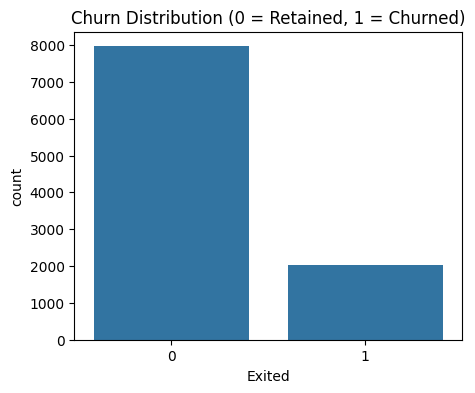

In [12]:
plt.figure(figsize=(5,4))
sns.countplot(x="Exited", data=df)
plt.title("Churn Distribution (0 = Retained, 1 = Churned)")
plt.show()


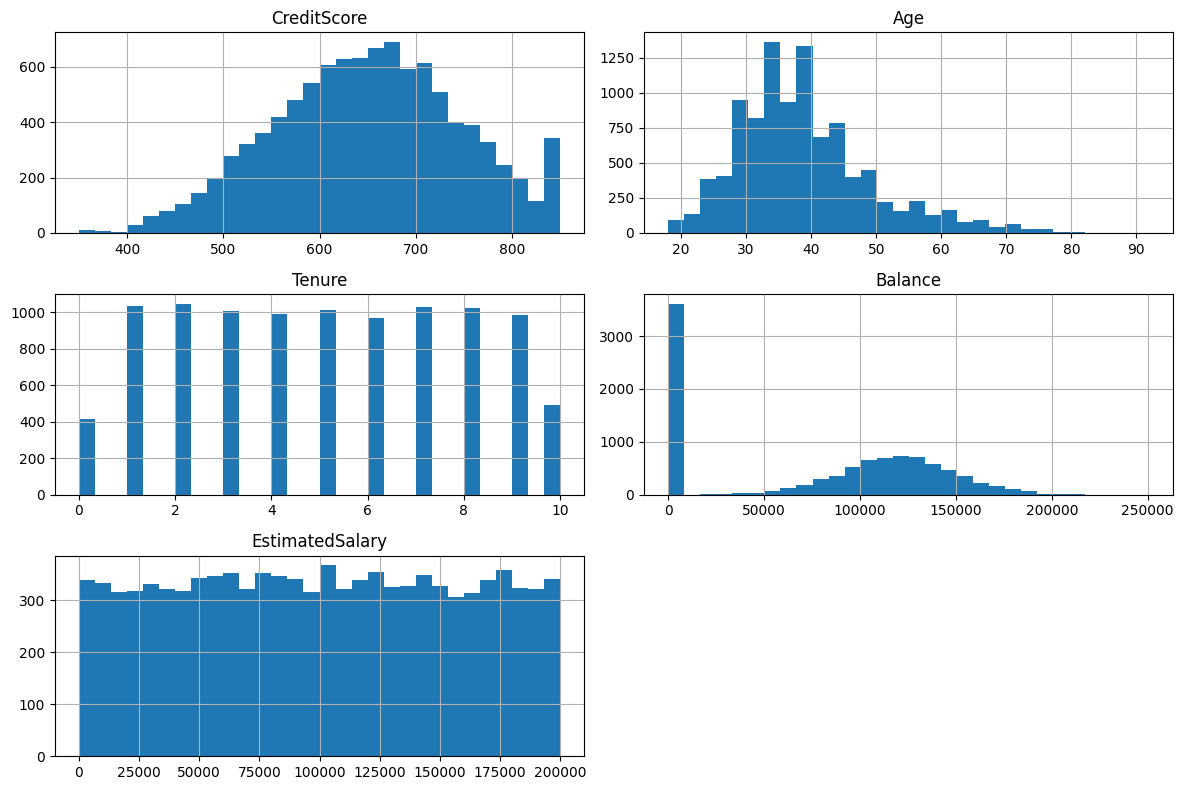

In [13]:
num_cols = ["CreditScore", "Age", "Tenure", "Balance", "EstimatedSalary"]
df[num_cols].hist(figsize=(12,8), bins=30)
plt.tight_layout()
plt.show()



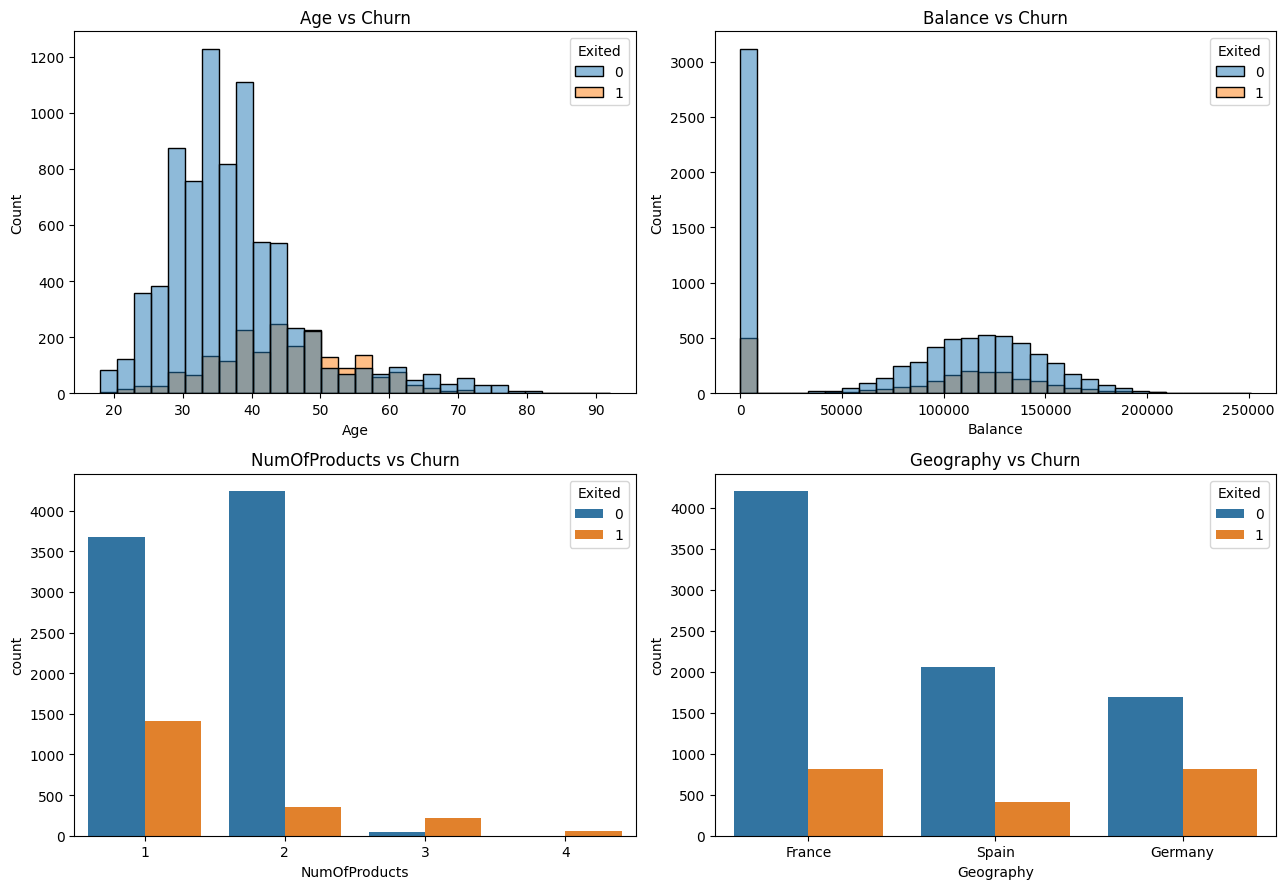

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(13,9))

sns.histplot(data=df, x="Age", hue="Exited", ax=axes[0,0], bins=30)
axes[0,0].set_title("Age vs Churn")

sns.histplot(data=df, x="Balance", hue="Exited", ax=axes[0,1], bins=30)
axes[0,1].set_title("Balance vs Churn")

sns.countplot(x="NumOfProducts", hue="Exited", data=df, ax=axes[1,0])
axes[1,0].set_title("NumOfProducts vs Churn")

sns.countplot(x="Geography", hue="Exited", data=df, ax=axes[1,1])
axes[1,1].set_title("Geography vs Churn")

plt.tight_layout()
plt.show()


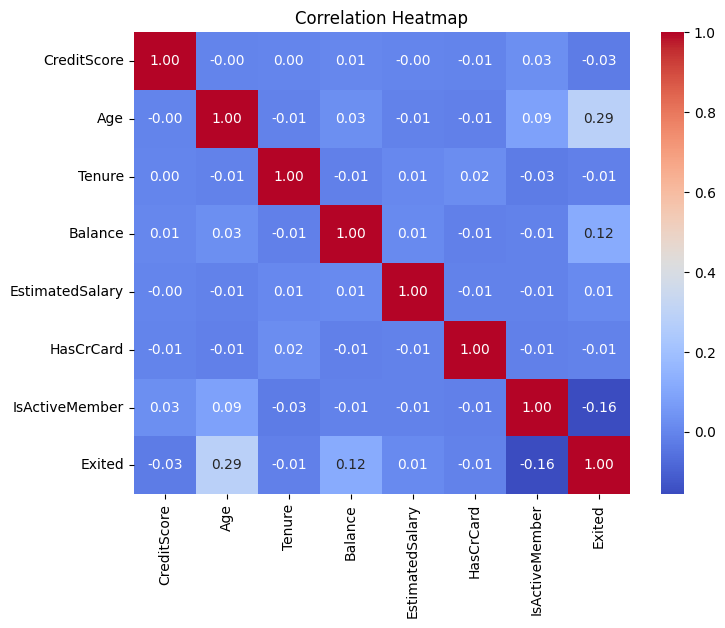

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + ["HasCrCard","IsActiveMember","Exited"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


## Feature Engineering
Derive behavioral features, one-hot encode categoricals.
We keep the raw (unscaled) engineered frame here; scaling happens AFTER the train/test split (Phase 3) to avoid data leakage.


In [16]:
df_fe = df.copy()

df_fe["HasBalance"] = (df_fe["Balance"] > 0).astype(int)


df_fe["BalanceSalaryRatio"] = df_fe["Balance"] / (df_fe["EstimatedSalary"] + 1)

df_fe["TenureByAge"] = df_fe["Tenure"] / (df_fe["Age"] + 1)

print("New columns added:", ["HasBalance", "BalanceSalaryRatio", "TenureByAge"])
df_fe.head()


New columns added: ['HasBalance', 'BalanceSalaryRatio', 'TenureByAge']


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455


In [17]:
df_fe = pd.get_dummies(
    df_fe,
    columns=["Geography", "Gender"],
    drop_first=True,
    dtype=int
)
print("Shape after encoding:", df_fe.shape)
df_fe.head()


Shape after encoding: (10000, 15)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,HasBalance,BalanceSalaryRatio,TenureByAge,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,0,0.000000,0.046512,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0.744670,0.023810,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1,1.401362,0.186047,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0.000000,0.025000,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,1.587035,0.045455,0,1,0


In [18]:
print("Target still present:", "Exited" in df_fe.columns)
print("Total columns:", df_fe.shape[1])
print("\nColumn list:\n", list(df_fe.columns))


Target still present: True
Total columns: 15

Column list:
 ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'HasBalance', 'BalanceSalaryRatio', 'TenureByAge', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
